In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, LeaveOneOut
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

In [4]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [5]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Train columns:\n", train.columns.tolist())
print("Target value counts:\n", train.iloc[:, -1].value_counts())
 

Train shape: (630000, 21)
Test shape : (270000, 20)
Train columns:
 ['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']
Target value counts:
 Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


In [6]:
 
TARGET = [col for col in train.columns if col not in test.columns][0]
ID_COL = 'id'
print(f"Target column : {TARGET}")
print(f"ID column     : {ID_COL}")
 

Target column : Irrigation_Need
ID column     : id



Features     : ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']
Classes      : ['High', 'Low', 'Medium']
X shape      : (630000, 19)
X_test shape : (270000, 19)
5-FOLD Stratified Cross Validation
  Decision Tree         : 0.9851 +/- 0.0002  [CV time: 14.3s]
  Naive Bayes           : 0.8271 +/- 0.0010  [CV time: 0.9s]
  Logistic Regression   : 0.7488 +/- 0.0008  [CV time: 3.7s]
  KNN                   : 0.8472 +/- 0.0013  [CV time: 634.0s]
  Random Forest         : 0.9853 +/- 0.0002  [CV time: 608.1s]
  Extra Trees           : 0.9693 +/- 0.0004  [CV time: 351.5s]
  LightGBM              : 0.9843 +/- 0.0002  [CV time: 3271.6s]
  XGBoost               : 0.9845 +/- 0.0003  [CV time: 119.8s]
  CatBoost              : 0.984

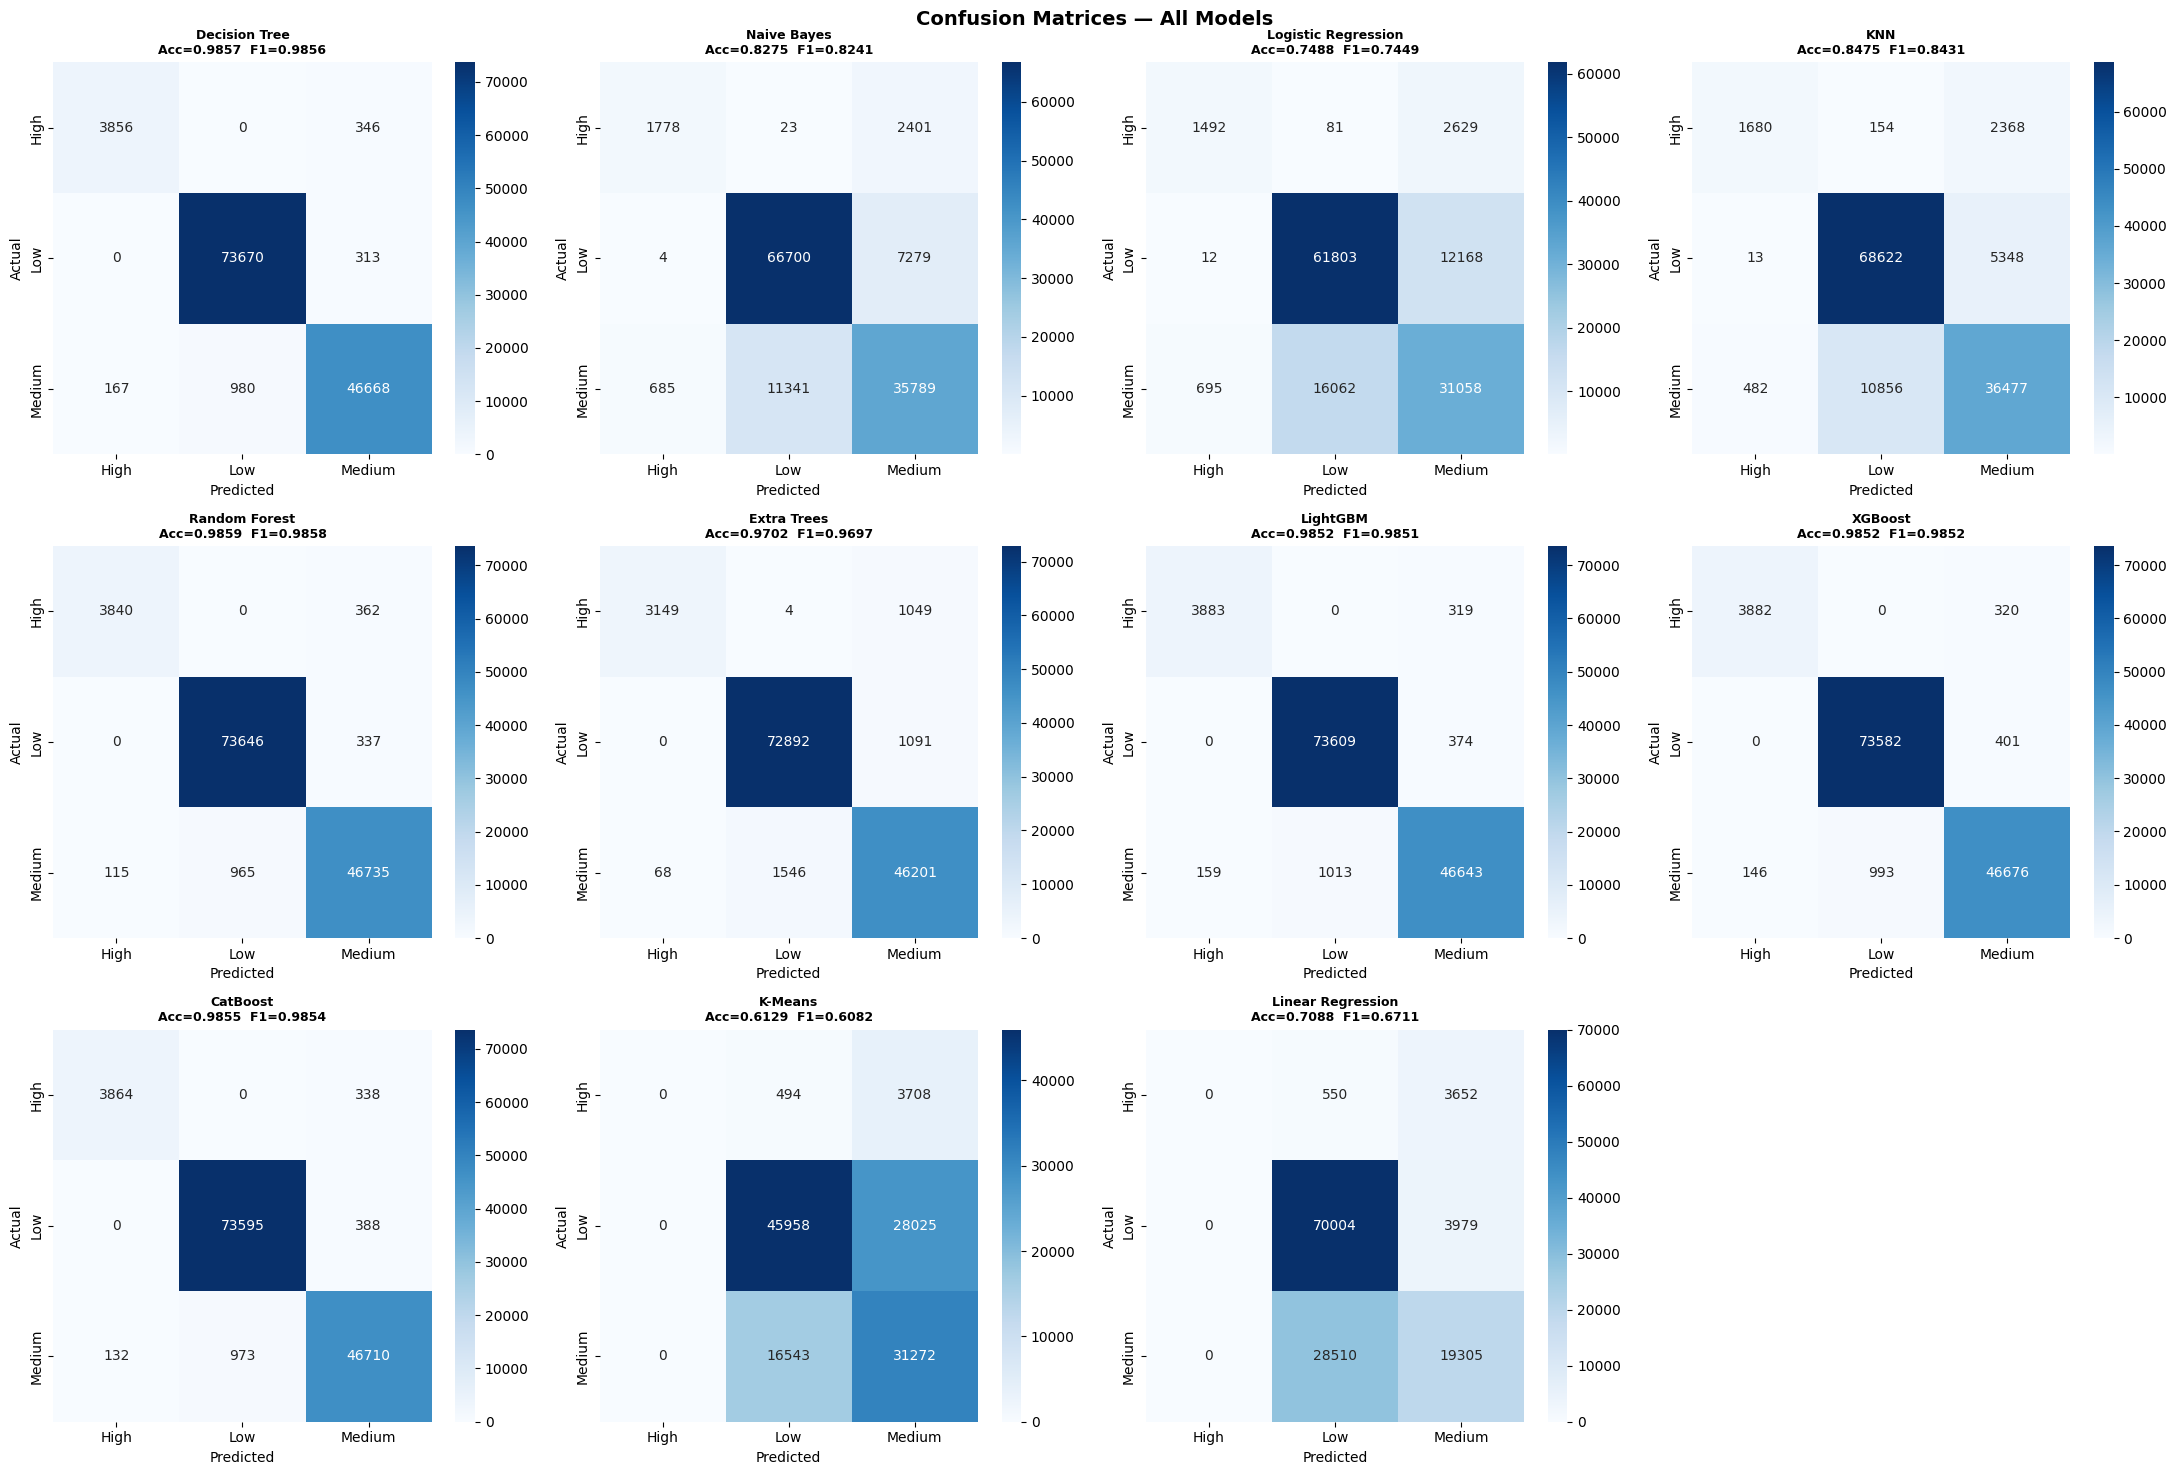

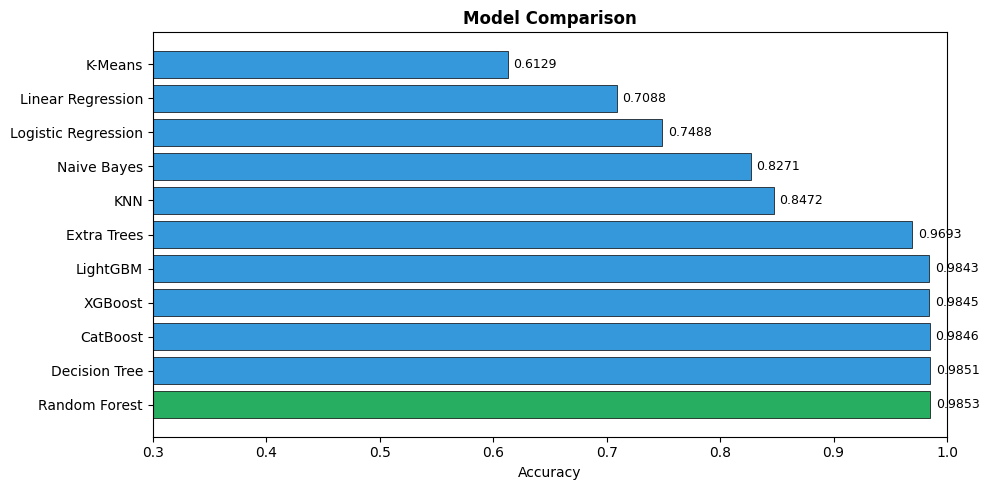

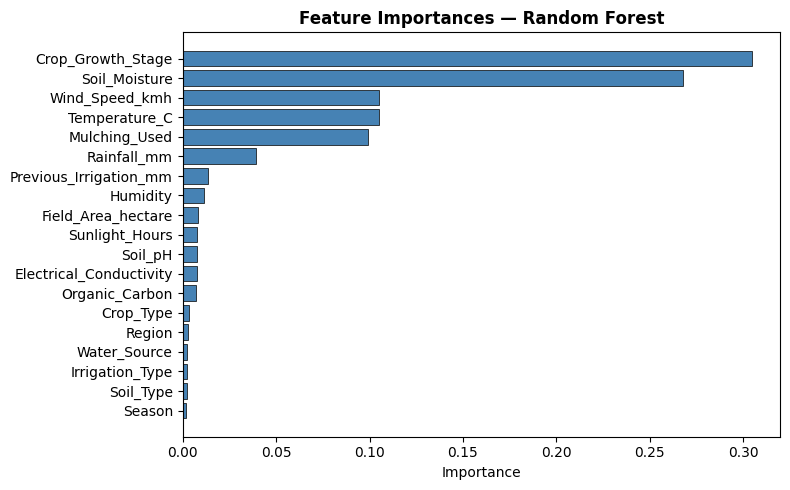


Top Features:
                Feature  Importance
      Crop_Growth_Stage    0.304411
          Soil_Moisture    0.267752
         Wind_Speed_kmh    0.105335
          Temperature_C    0.104956
          Mulching_Used    0.099405
            Rainfall_mm    0.039533
 Previous_Irrigation_mm    0.013362
               Humidity    0.011231
     Field_Area_hectare    0.008165
         Sunlight_Hours    0.007920
                Soil_pH    0.007886
Electrical_Conductivity    0.007817
         Organic_Carbon    0.007151
              Crop_Type    0.003183
                 Region    0.002788
           Water_Source    0.002461
        Irrigation_Type    0.002460
              Soil_Type    0.002376
                 Season    0.001807

Best Model : Random Forest
Best Acc   : 0.9859

submission.csv saved!
Preview:
        id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6 

In [7]:
import time
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

X = train.drop(columns=[ID_COL, TARGET])
y_raw  = train[TARGET]
X_test = test.drop(columns=[ID_COL])
 
# Encode categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
encoders = {}
for col in cat_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[col]      = enc.fit_transform(X[[col]])
    X_test[col] = enc.transform(X_test[[col]])
    encoders[col] = enc
 
# Encode target
le = LabelEncoder()
y  = le.fit_transform(y_raw)
 
print(f"\nFeatures     : {list(X.columns)}")
print(f"Classes      : {list(le.classes_)}")
print(f"X shape      : {X.shape}")
print(f"X_test shape : {X_test.shape}")
 
# Scaled versions (for models that need it)
scaler    = StandardScaler()
X_sc      = scaler.fit_transform(X)
X_test_sc = scaler.transform(X_test)
 
n_classes = len(le.classes_)
SEED      = 42
NEEDS_SCALE = ['Logistic Regression', 'KNN']
 
def get_X(name, scaled, raw):
    return scaled if name in NEEDS_SCALE else raw
 

km = KMeans(n_clusters=n_classes, random_state=SEED, n_init=10)
km.fit(X_sc)
 
# Map each cluster to the most common true class in that cluster
cluster_to_class = {}
for cid in range(n_classes):
    mask = km.labels_ == cid
    if mask.sum() > 0:
        cluster_to_class[cid] = pd.Series(y[mask]).mode()[0]
    else:
        cluster_to_class[cid] = 0
 
def kmeans_predict(data_scaled):
    return np.array([cluster_to_class[c] for c in km.predict(data_scaled)])
 

lr_reg = LinearRegression()
lr_reg.fit(X_sc, y)
 
def linreg_predict(data_scaled):
    raw = lr_reg.predict(data_scaled)
    return np.clip(np.round(raw).astype(int), 0, n_classes - 1)
 

models = {
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=SEED),
    'Naive Bayes'         : GaussianNB(),
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    # ── NEW ──
    'LightGBM'            : LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                           num_leaves=63, random_state=SEED,
                                           verbose=-1, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=6, random_state=SEED,
                                          eval_metric='mlogloss',
                                          verbosity=0, n_jobs=-1),
    'CatBoost'            : CatBoostClassifier(iterations=300, learning_rate=0.05,
                                               depth=6, random_state=SEED,
                                               verbose=0),
}
 

print("5-FOLD Stratified Cross Validation")
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}
 
for name, model in models.items():
    t0 = time.time()
    scores = cross_val_score(model, get_X(name, X_sc, X), y,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f"  {name:<22}: {scores.mean():.4f} +/- {scores.std():.4f}  [CV time: {elapsed:.1f}s]")
 

print("LOOCV On 300-Sample Subset")

loo   = LeaveOneOut()
X_sub = X.iloc[:300]
y_sub = y[:300]
 
for name in ['Decision Tree', 'Naive Bayes']:
    s = cross_val_score(models[name], X_sub, y_sub,
                        cv=loo, scoring='accuracy', n_jobs=-1)
    print(f"  {name:<22}: {s.mean():.4f}")
 

print("Holdout evaluation (80/20 Split)")

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
 
results = {}
 
# Standard models
for name, model in models.items():
    Xtr = X_tr_sc if name in NEEDS_SCALE else X_tr
    Xvl = X_val_sc if name in NEEDS_SCALE else X_val
    t0 = time.time()
    model.fit(Xtr, y_tr)
    elapsed = time.time() - t0
    preds = model.predict(Xvl)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='weighted')
    results[name] = {'accuracy': acc, 'f1': f1,
                     'cm': confusion_matrix(y_val, preds)}
    print(f"  {name:<22}: acc={acc:.4f}  f1={f1:.4f}  [train: {elapsed:.1f}s]")
 
# K-Means on holdout
km_preds = kmeans_predict(X_val_sc)
results['K-Means'] = {
    'accuracy': accuracy_score(y_val, km_preds),
    'f1'      : f1_score(y_val, km_preds, average='weighted'),
    'cm'      : confusion_matrix(y_val, km_preds)
}
print(f"  {'K-Means':<22}: acc={results['K-Means']['accuracy']:.4f}  f1={results['K-Means']['f1']:.4f}")
 
# Linear Regression on holdout
lr_preds = linreg_predict(X_val_sc)
results['Linear Regression'] = {
    'accuracy': accuracy_score(y_val, lr_preds),
    'f1'      : f1_score(y_val, lr_preds, average='weighted'),
    'cm'      : confusion_matrix(y_val, lr_preds)
}
print(f"  {'Linear Regression':<22}: acc={results['Linear Regression']['accuracy']:.4f}  f1={results['Linear Regression']['f1']:.4f}")
 

all_names = list(models.keys()) + ['K-Means', 'Linear Regression']
ncols = 4
nrows = (len(all_names) + ncols - 1) // ncols
 
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()
 
for idx, name in enumerate(all_names):
    cm  = results[name]['cm']
    acc = results[name]['accuracy']
    f1  = results[name]['f1']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name}\nAcc={acc:.4f}  F1={f1:.4f}',
                        fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
 
for idx in range(len(all_names), len(axes)):
    axes[idx].set_visible(False)
 
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
 

all_cv = {k: v.mean() for k, v in cv_results.items()}
all_cv['K-Means']           = results['K-Means']['accuracy']
all_cv['Linear Regression'] = results['Linear Regression']['accuracy']
 
sorted_names = sorted(all_cv, key=all_cv.get, reverse=True)
colors = ['#27ae60' if n == sorted_names[0] else '#3498db' for n in sorted_names]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_names, [all_cv[n] for n in sorted_names],
               color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison', fontweight='bold')
ax.set_xlim(0.3, 1.0)
for bar, val in zip(bars, [all_cv[n] for n in sorted_names]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
 

importances = models['Random Forest'].feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importance')
ax.set_title('Feature Importances — Random Forest', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\nTop Features:")
print(feat_df.to_string(index=False))
 

best_name = max(results, key=lambda k: results[k]['accuracy'])
best_acc  = results[best_name]['accuracy']
print(f"\nBest Model : {best_name}")
print(f"Best Acc   : {best_acc:.4f}")
 
scaler_full = StandardScaler()
X_full_sc   = scaler_full.fit_transform(X)
X_test_sc_f = scaler_full.transform(X_test)
 
if best_name == 'K-Means':
    km.fit(X_full_sc)
    for cid in range(n_classes):
        mask = km.labels_ == cid
        if mask.sum() > 0:
            cluster_to_class[cid] = pd.Series(y[mask]).mode()[0]
    test_preds_enc = kmeans_predict(X_test_sc_f)
 
elif best_name == 'Linear Regression':
    lr_reg.fit(X_full_sc, y)
    test_preds_enc = linreg_predict(X_test_sc_f)
 
elif best_name in NEEDS_SCALE:
    models[best_name].fit(X_full_sc, y)
    test_preds_enc = models[best_name].predict(X_test_sc_f)
 
else:
    models[best_name].fit(X, y)
    test_preds_enc = models[best_name].predict(X_test)
 
test_preds = le.inverse_transform(test_preds_enc)
 

submission = pd.DataFrame({
    'id'   : test[ID_COL],
    TARGET : test_preds
})
submission.to_csv('submission.csv', index=False)
 
print("\nsubmission.csv saved!")
print("Preview:\n", submission.head(10))
print("\nPrediction distribution:\n", submission[TARGET].value_counts())
 

print("Final results summary")
 
rows = [{'Model': n,
         'Holdout Acc': f"{results[n]['accuracy']:.4f}",
         'F1 (weighted)': f"{results[n]['f1']:.4f}"}
        for n in all_names]
 
summary = pd.DataFrame(rows).sort_values('Holdout Acc', ascending=False)
print(summary.to_string(index=False))
print(f"Best Model : {best_name}")
print(f"Best Acc   : {best_acc:.4f}")
print("Files saved:")
print("  submission.csv")
print("  confusion_matrices.png")
print("  model_comparison.png")
print("  feature_importance.png")